<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
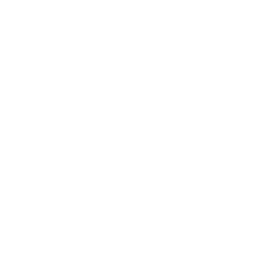
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Hospital Department Resource Utilization — Horizontal Bar Chart</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Healthcare / Hospital Operations &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This example uses **PROC GCHART** horizontal bar charts (HBAR) to profile staff-hours across six clinical departments for Q1 2026. A synthetic workforce log of **90 shift records** (15 per department) drives three views: a ranked total-hours bar chart, mean shift length per department, and grouped HBARs that split each department by resource category and by shift. `SUMVAR=` accumulates actual labor hours rather than counting records, `TYPE=SUM`/`TYPE=MEAN` switch the response statistic, `DESCENDING` ranks departments, and `GROUP=` draws adjacent clustered bars for a second dimension.

The output supports the quarterly operational efficiency review: it surfaces which departments consume the most labor, which run the longest shifts, and how the day/swing/night staffing pattern differs between continuous-acuity units and daytime-oriented services.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Individual shift labor records with hours worked | 90 |
| WORK.DEPT_SUMMARY | Department-level totals and mean shift length | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic hospital staffing labor log.
   Q1 2026: 6 clinical departments, 4 resource categories,
   3 shifts. Sized to 15 shift records per department
   (90 total) so the full department roster stays visible.
   -------------------------------------------------------- */
data work.staffing_log;
    call streaminit(20260601);
    length department $20 resource_type $14 shift $6;

    array dept[6] $20 _temporary_
        ('Emergency' 'Surgery' 'ICU' 'Pediatrics'
         'Oncology' 'Maternity');

    /* resource-category mix (nursing-heavy clinical staffing) */
    array res[4]  $14 _temporary_
        ('Nursing' 'Physician' 'Allied Health' 'Support');
    array resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baseline shift mix, tilted toward Night for 24/7 units */
    array shfw[3] _temporary_ (0.45 0.30 0.25);
    array nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    do di = 1 to 6;
        department = dept[di];
        do rec = 1 to 15;

            /* resource type via weighted draw */
            u = rand('uniform'); cum = 0;
            do r = 1 to 4;
                cum + resw[r];
                if u <= cum then do;
                    resource_type = res[r];
                    leave;
                end;
            end;

            /* shift via department-specific night tilt */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            if u <= w1 then shift = 'Day';
            else if u <= w1 + w2 then shift = 'Swing';
            else shift = 'Night';

            /* hours: physicians and surgery run longer shifts */
            base = 8;
            if resource_type = 'Physician' then base = base + 1.5;
            if department = 'Surgery'      then base = base + 1.0;
            hours_worked = round(base + rand('normal', 0, 0.8), 0.25);
            if hours_worked < 4 then hours_worked = 4;

            output;
        end;
    end;
    keep department resource_type shift hours_worked;
run;

NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Department-level totals and mean shift length,
   ranked by total labor hours.
   -------------------------------------------------------- */
proc sql;
    create table work.dept_summary as
    select department,
           sum(hours_worked)  as total_hours   format=8.2,
           count(*)           as shift_count,
           mean(hours_worked) as avg_shift_hrs  format=6.2
    from work.staffing_log
    group by department
    order by total_hours desc;
quit;

proc print data=work.dept_summary noobs label;
    label total_hours   = 'Total Hours'
          shift_count   = 'Shifts'
          avg_shift_hrs = 'Mean Shift (hrs)';
    title 'Department Labor Summary - Q1 2026';
run;
title;

                                           Department Labor Summary - Q1 2026                                           

department  Total Hours  Shifts  Mean Shift (hrs)
Surgery          136.25      15              9.08
ICU              128.50      15              8.57
Maternity        127.75      15              8.52
Pediatrics       124.75      15              8.32
Oncology         123.75      15              8.25
Emergency        119.25      15              7.95



NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                               Labor Hours by Department                                                

                                                  The MEANS Procedure

                                            Analysis Variable : hours_worked

        department            Sum           Mean          N Obs
        -------------------------------------------------------
        Emergency          119.25           7.95             15
        ICU                128.50           8.57             15
        Maternity          127.75           8.52             15
        Oncology           123.75           8.25             15
        Pediatrics         124.75           8.32             15
        Surgery            136.25           9.08             15
        -------------------------------------------------------

                                            Shift Distribution by Department                                            

                              

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


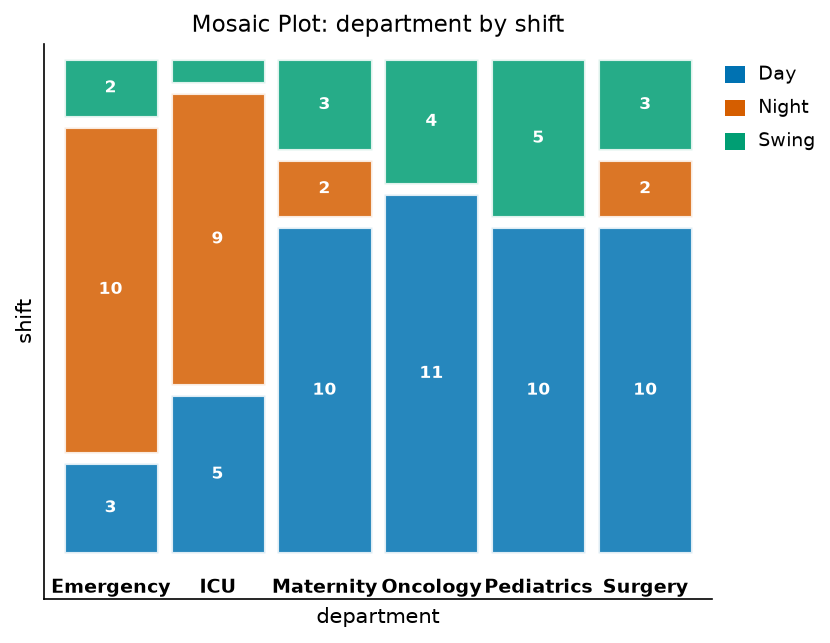

In [3]:
/* --------------------------------------------------------
   Baseline tables: labor hours by department, and the
   day / swing / night shift distribution per department.
   -------------------------------------------------------- */
proc means data=work.staffing_log sum mean n maxdec=2;
    class department;
    var hours_worked;
    title 'Labor Hours by Department';
run;

proc freq data=work.staffing_log;
    tables department * shift / norow nocol nopercent;
    title 'Shift Distribution by Department';
run;
title;

---

NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


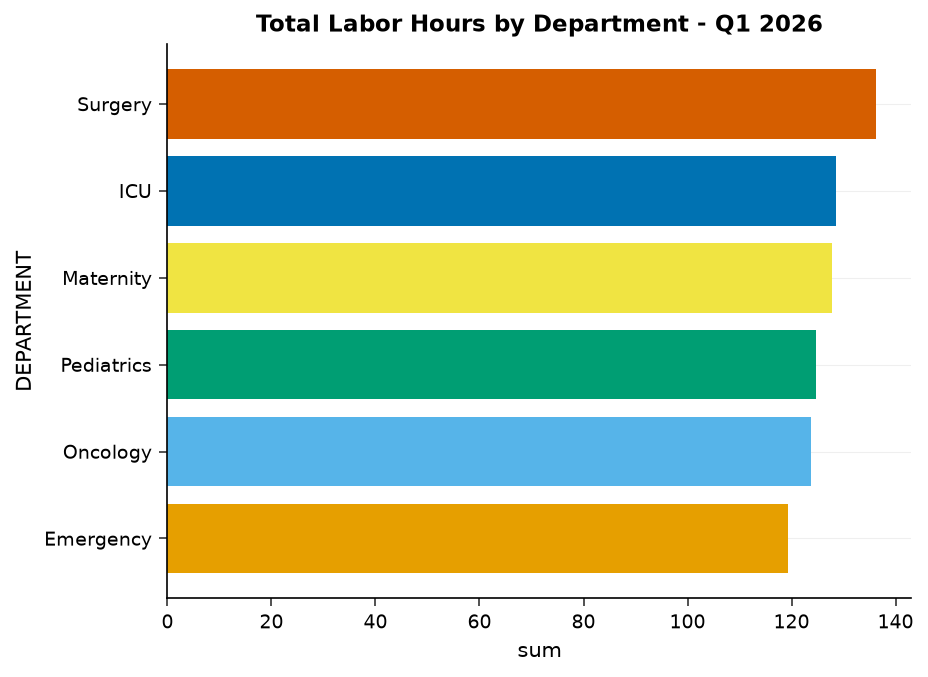

In [4]:
/* --------------------------------------------------------
   Overview HBAR: total labor hours by department.
   SUMVAR= accumulates hours; DESCENDING ranks the bars.
   -------------------------------------------------------- */
proc gchart data=work.staffing_log;
    hbar department / sumvar=hours_worked
                      type=sum
                      descending;
    title 'Total Labor Hours by Department - Q1 2026';
run;
quit;
title;

### Splitting each department by resource category

`GROUP=` draws a cluster of adjacent horizontal bars for every department, one bar per resource category. Because `SUMVAR=hours_worked` is in force, each bar measures accumulated labor hours rather than a record count, so the chart shows how nursing, physician, allied-health, and support hours compare *within* each department.

In [5]:
/* --------------------------------------------------------
   PATTERN statements: coordinated 4-color palette
   one pattern per resource type subgroup
   -------------------------------------------------------- */
pattern1 value=solid color=cx2C5F8A;   /* Nursing — deep blue   */
pattern2 value=solid color=cx28A745;   /* Physician — green     */
pattern3 value=solid color=cxE8650A;   /* Allied Health — amber */
pattern4 value=solid color=cx6C757D;   /* Support Staff — gray  */

                                      Department Labor Hours by Resource Category                                       


Source: Workforce Management System | Reporting period: Jan-Mar 2026


NOTE: Option TITLE changed to Department Labor Hours by Resource Category.
NOTE: Option FOOTNOTE changed to Source: Workforce Management System | Reporting period: Jan-Mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


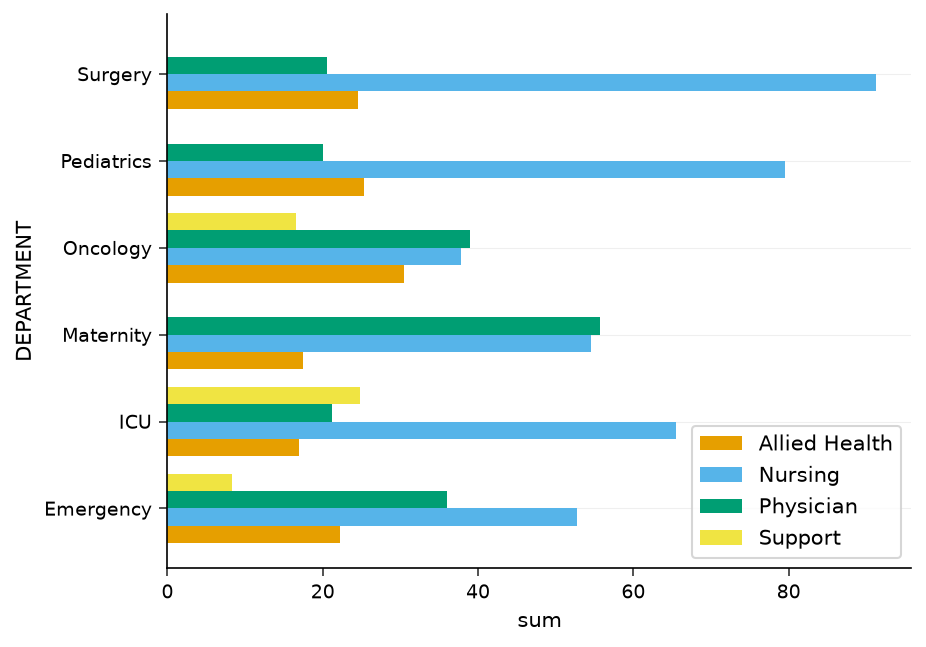

In [6]:
/* --------------------------------------------------------
   HBAR grouped by resource category (GROUP=).
   Each department becomes a cluster of bars -- one per
   resource type -- measured in accumulated labor hours.
   -------------------------------------------------------- */
title 'Department Labor Hours by Resource Category';
footnote justify=left
    'Source: Workforce Management System | Reporting period: Jan-Mar 2026';

proc gchart data=work.staffing_log;
    hbar department / group=resource_type
                      sumvar=hours_worked
                      type=sum;
run;
quit;

title; footnote;

                                            Department Labor Hours by Shift                                             


Grouped bars separate Day / Swing / Night contributions per department


NOTE: Option TITLE changed to Department Labor Hours by Shift.
NOTE: Option FOOTNOTE changed to Grouped bars separate Day / Swing / Night contributions per department.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


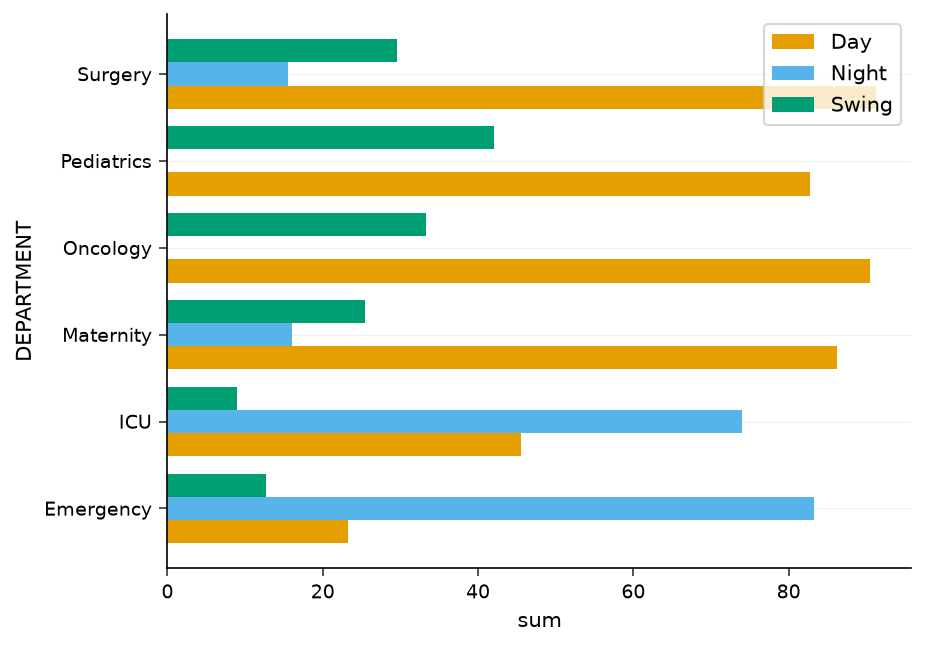

In [7]:
/* --------------------------------------------------------
   HBAR grouped by shift (GROUP=).
   Separates Day / Swing / Night labor hours within each
   department -- highlighting the 24/7 acuity units.
   -------------------------------------------------------- */
title 'Department Labor Hours by Shift';
footnote justify=left
    'Grouped bars separate Day / Swing / Night contributions per department';

proc gchart data=work.staffing_log;
    hbar department / group=shift
                      sumvar=hours_worked
                      type=sum;
run;
quit;

title; footnote;

NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


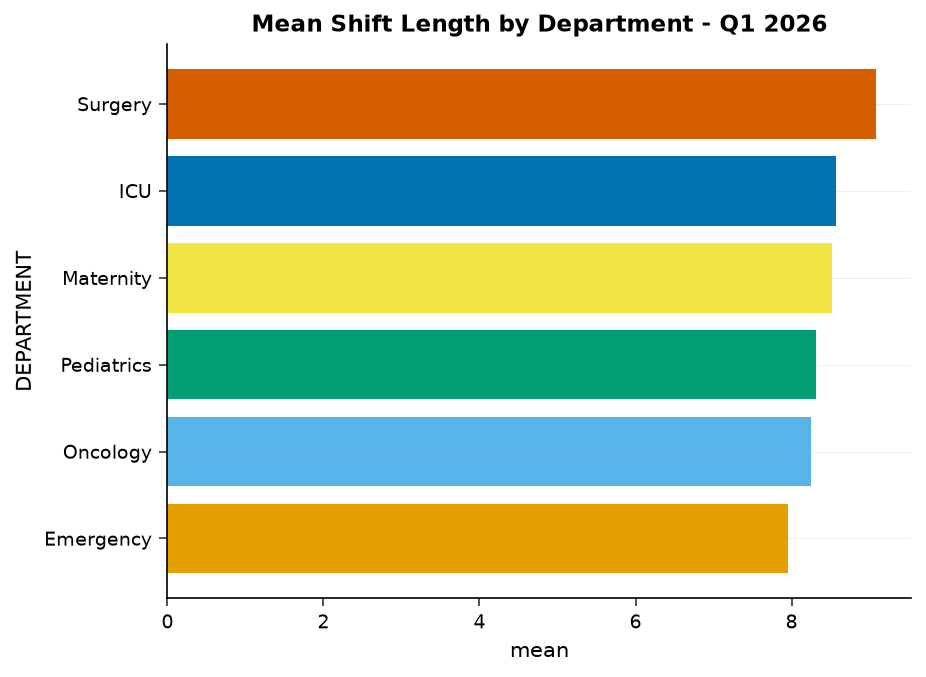

In [8]:
/* --------------------------------------------------------
   Mean shift length per department (TYPE=MEAN).
   Reveals whether a department runs long shifts or many
   shorter ones, independent of total volume.
   -------------------------------------------------------- */
proc gchart data=work.staffing_log;
    hbar department / sumvar=hours_worked
                      type=mean
                      descending;
    title 'Mean Shift Length by Department - Q1 2026';
run;
quit;
title;

---

### Interpretation

Across the 90 shift records, total labor hours run in a narrow band from **119.25** (Emergency) to **136.25** (Surgery) because every department carries the same 15 shifts in this period — so the ranking reflects **shift length**, not shift count. Surgery tops both the total-hours chart and the mean-shift chart at **9.08 hours** per shift, consistent with longer operative cases and the physician-heavy staffing those cases require. Emergency sits at the bottom on hours (**7.95** mean) despite being one of the busiest units, because its work is delivered in shorter, higher-turnover shifts.

The shift-grouped HBAR and the mosaic panel tell the operationally important story. **Emergency and ICU are night-dominant** — 10 of 15 and 9 of 15 shifts respectively fall on Night — while **Oncology and Pediatrics record no Night shifts at all** and concentrate on Day coverage (11 and 10 Day shifts). That split mirrors real hospital staffing: continuous-acuity units run around the clock, whereas oncology infusion and general pediatrics are daytime services. The resource-category panel confirms a **nursing-led mix** in every department, with physician and allied-health hours forming the secondary tiers.

For the Q2 staffing review, the night-shift concentration in Emergency and ICU is the line item to watch: it is where premium-rate and fatigue-management costs accumulate, and where any change to the rotation has the largest budget impact.

---

In [9]:
/* --------------------------------------------------------
   Export the department summary for the workforce
   planning system.
   -------------------------------------------------------- */
proc export data=work.dept_summary
    outfile='q1_dept_labor_summary.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>